# Exact Hessian and truncated conjugate gradient on the quartic saddle

The test function is

$$f(p) = p_1^4 - p_1^3 + \left(\tfrac14 - \tfrac{p_1}{2}\right)p_2^2 + \tfrac{p_2^4}{4},$$

with four critical points. The origin is degenerate, $\nabla^2 f(0,0)$ being
singular and positive semidefinite. The point $(0.75, 0)$ is a strict saddle with
$\lambda_{\min} = -1/4$. The two local minimisers sit at
$\left(\tfrac{1+\sqrt5}{4}, \pm\sqrt{\tfrac{\sqrt5-1}{4}}\right)$.

Every run goes through `tr_solve`. The setup comes from `saddle_problem.jl`.
Nothing below defines a rule, a model, a subsolver or a trust-region loop.

In [1]:
const SADDLEDIR = @__DIR__
using Pkg; Pkg.activate(joinpath(SADDLEDIR, "..", ".."))
include(joinpath(SADDLEDIR, "..", "saddle_problem.jl"))

critical_points_table()

  Activating project at `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks`


Critical points of f

name     x                              f(x)     ||grad||              eig(hess)
--------------------------------------------------------------------------------
origin   (+0.000000, +0.000000)   0.00000000     0.00e+00   (-0.00000, +0.50000)
saddle   (+0.750000, +0.000000)  -0.10546875     0.00e+00   (-0.25000, +2.25000)
min+     (+0.809017, +0.555893)  -0.12500000     3.93e-17   (+0.49469, +3.12334)
min-     (+0.809017, -0.555893)  -0.12500000     3.93e-17   (+0.49469, +3.12334)


## 1. A small cap degenerates R-grad

`R-grad` capped bounds the multiplier by $\bar\mu$, which the asymptotic theory
needs. The radius $\Delta_k = \mu_k\|g_k\|$ is then small everywhere. A small
region makes the linear term of the model dominate its quadratic term, the step
that comes back points along $-g_k$, and the model Hessian has stopped
influencing the direction.

The table carries the three columns already in use and the corrected forms
beside them. The corrected ones are what the report quotes.

`cos last` is the cosine at the final iterate, which is one number out of
however many iterations ran. `cos min` is the minimum over the run and `cos frac`
the fraction of iterations within $10^{-12}$ of one. A run that is gradient
descent throughout has `cos min` equal to one; a run that is gradient descent at
the end alone does not.

`cauchy` is the single Cauchy percentage. `trunc`, `inside` and `krylov` are the
three step classes. Only `trunc` is gradient descent in disguise, the region
having truncated conjugate gradient on its first direction, which is $-g_k$.

The limit is a name, a distance and $\|g\|$. A run that exhausted its budget
while still moving is not a run that converged somewhere else.

In [2]:
const MU_SWEEP   = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 4.0, 8.0, 128.0]
const ZETA_SWEEP = [0.1, 0.5, 1.0, 2.0, 5.0, 20.0]

mk_cap(μm) = RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3, μ = min(MU0, μm), μ_max = μm)
mk_dfo(ζ)  = RDFO(γ1 = G1, γ2 = G2, γ3 = G3, ζ = ζ)

"""
    sweep_row(rule, subsolver) -> NamedTuple

One `tr_solve`, reduced to the columns of the table. Every entry is read from
`stats.solver_specific` or from a diagnostic of `saddle_problem.jl`. Nothing is
recomputed from the iterates.
"""
function sweep_row(rule; subsolver = SteihaugCG(), model = ExactHessian(),
                   tol_H = -1.0, x0 = X0_DEFAULT)
    st, xs = solve_path(rule = rule, model = model, subsolver = subsolver,
                        tol_H = tol_H, x0 = x0, kmax = KMAX, tol = TOL)
    ss = st.solver_specific
    cosc = ss[:cos_cauchy_trajectory]
    Δ    = ss[:delta_trajectory]
    tr, ins, kry = step_classes(ss)
    nc = nearest_crit(st.solution)
    fin = filter(isfinite, cosc)
    return (st = st, xs = xs, status = st.status, iter = st.iter,
            cauchy   = hypotheses_report(st).cauchy_fraction,
            cos_last = isempty(fin) ? NaN : fin[end],
            cos_min  = isempty(fin) ? NaN : minimum(fin),
            cos_frac = isempty(cosc) ? NaN :
                       count(x -> isfinite(x) && x > 1 - 1e-12, cosc) / length(cosc),
            trunc = tr, inside = ins, krylov = kry,
            tail  = active_fraction(st; tail = 0.1),
            limit = nc.name, dist = nc.dist,
            gnorm = Float64(st.dual_feas),
            delta_end = Δ[end], delta_min = minimum(Δ))
end

function sweep_table(rows, params, pname; title = "")
    isempty(title) || (println("\n", "="^128); println(title); println("="^128))
    @printf("%8s %10s %6s | %8s %8s | %9s %9s %9s | %8s %8s %8s | %8s | %-7s %9s %9s\n",
            pname, "status", "iter", "cauchy", "cos last",
            "cos min", "cos frac", "tail act", "trunc", "inside", "krylov",
            "Delta end", "limit", "dist", "|g|")
    println("-"^128)
    for (p, r) in zip(params, rows)
        @printf("%8.2f %10s %6d | %8.4f %8.5f | %9.6f %9.4f %9.4f | %8.4f %8.4f %8.4f | %8.2e | %-7s %9.2e %9.2e\n",
                p, string(r.status), r.iter, r.cauchy, r.cos_last,
                r.cos_min, r.cos_frac, r.tail, r.trunc, r.inside, r.krylov,
                r.delta_end, r.limit, r.dist, r.gnorm)
    end
end

CAP_CG = [sweep_row(mk_cap(μm)) for μm in MU_SWEEP]
sweep_table(CAP_CG, MU_SWEEP, "mu_max";
            title = "TABLE 1. R-grad capped, exact Hessian, truncated CG.")


TABLE 1. R-grad capped, exact Hessian, truncated CG.
  mu_max     status   iter |   cauchy cos last |   cos min  cos frac  tail act |    trunc   inside   krylov | Delta end | limit        dist       |g|
--------------------------------------------------------------------------------------------------------------------------------
    0.01   max_iter   2000 |   1.0000  1.00000 |  1.000000    1.0000    1.0000 |   1.0000   0.0000   0.0000 | 6.17e-06 | origin   1.42e-02  6.17e-04
    0.05   max_iter   2000 |   1.0000  1.00000 |  1.000000    1.0000    1.0000 |   1.0000   0.0000   0.0000 | 1.53e-06 | origin   3.19e-03  3.07e-05
    0.10   max_iter   2000 |   1.0000  1.00000 |  1.000000    1.0000    1.0000 |   1.0000   0.0000   0.0000 | 7.93e-07 | origin   1.62e-03  7.93e-06
    0.30   max_iter   2000 |   0.9995  1.00000 |  0.877285    0.9995    1.0000 |   0.9995   0.0000   0.0005 | 2.72e-07 | origin   5.50e-04  9.08e-07
    0.50   max_iter   2000 |   0.9990  1.00000 |  0.877285    0.9990   

## 2. The zeta sweep for R-DFO

`R-DFO` holds $\Delta_k$ below $\zeta\omega_k$, so a small $\zeta$ is the other
way of keeping the region small. The sweep runs $\zeta$ over more than two
decades at otherwise identical settings.

In [3]:
DFO_CG = [sweep_row(mk_dfo(ζ)) for ζ in ZETA_SWEEP]
sweep_table(DFO_CG, ZETA_SWEEP, "zeta";
            title = "TABLE 2. R-DFO, exact Hessian, truncated CG.")

# The finding is whether the swept parameter decides anything. Computed, not
# asserted, so the prose below quotes a cell that ran.
let it = unique(r.iter for r in DFO_CG),
    li = unique(r.limit for r in DFO_CG),
    st = unique(string(r.status) for r in DFO_CG),
    de = unique(r.delta_end for r in DFO_CG)
    println()
    @printf("distinct iteration counts over the zeta sweep : %d  %s\n", length(it), it)
    @printf("distinct limit points                         : %d  %s\n", length(li), li)
    @printf("distinct statuses                             : %d  %s\n", length(st), st)
    @printf("distinct final radii                          : %d\n", length(de))
    println()
    if length(it) == 1 && length(li) == 1 && length(st) == 1
        println("VERDICT: over more than two decades of zeta the iteration count, the")
        println("         status and the limit point are all the same. Only the final")
        @printf("         radius moves, and it takes %d distinct values over %d settings.\n",
                length(de), length(DFO_CG))
        println("         On this problem zeta does not decide the outcome. The table")
        println("         is that finding and not a sweep.")
    else
        println("VERDICT: zeta changes the outcome. The table is a sweep.")
    end
end


TABLE 2. R-DFO, exact Hessian, truncated CG.
    zeta     status   iter |   cauchy cos last |   cos min  cos frac  tail act |    trunc   inside   krylov | Delta end | limit        dist       |g|
--------------------------------------------------------------------------------------------------------------------------------
    0.10 first_order     16 |   0.3750  1.00000 |  0.877285    0.3750    0.0000 |   0.0000   0.3750   0.6250 | 1.53e-05 | origin   1.30e-05  5.06e-10
    0.50 first_order     16 |   0.3750  1.00000 |  0.877285    0.3750    0.0000 |   0.0000   0.3750   0.6250 | 1.53e-05 | origin   1.30e-05  5.06e-10
    1.00 first_order     16 |   0.3750  1.00000 |  0.877285    0.3750    0.0000 |   0.0000   0.3750   0.6250 | 6.10e-05 | origin   1.30e-05  5.06e-10
    2.00 first_order     16 |   0.3750  1.00000 |  0.877285    0.3750    0.0000 |   0.0000   0.3750   0.6250 | 6.10e-05 | origin   1.30e-05  5.06e-10
    5.00 first_order     16 |   0.3750  1.00000 |  0.877285    0.3750    0.

## 3. Can second-order machinery save the run from the origin?

The prediction, to test rather than to assume. At the origin
$\nabla^2 f = \operatorname{diag}(0, 1/2)$, so $\lambda_{\min} = 0$. The
second-order stopping test certifies $\lambda_{\min} \geq -\texttt{tol\_H}$ for
any $\texttt{tol\_H} > 0$, since $0 \geq -\texttt{tol\_H}$, so it cannot reject
the origin. And $\tau = \max\{\|g\|, -\lambda^-\} = \|g\|$ there, so the
second-order measure equals the first-order one.

Both pieces of machinery detect strictly negative curvature. A degenerate point
has none.

The contrast is what makes this a result. At $(0.75, 0)$, where
$\lambda_{\min} = -1/4$, the same test must refuse.

In [4]:
println("The measure and the test at each critical point\n")
@printf("%-8s %-24s %10s %12s %10s %14s\n",
        "name", "x", "|g|", "lambda_min", "tau", "test at tol_H=1e-6")
println("-"^88)
for (nm, p) in CRITPTS
    gn = norm(grad(p))
    λ  = eigvals(Symmetric(hess(p)))[1]
    τ  = tau_criticality(gn, λ)
    s  = second_order_status(gn, λ, 1e-9, 1e-6)
    @printf("%-8s (%+.6f, %+.6f) %10.2e %12.8f %10.2e %14s\n",
            nm, p[1], p[2], gn, λ, τ, string(s))
end

println("\nlambda_min at the origin, full precision: ",
        eigvals(Symmetric(hess(ORIGIN)))[1])

# Two runs started exactly on the critical point, second-order test on.
#
# Both subsolvers are run. At the saddle the gradient is zero, and `ExactMS`
# returns the zero step there by its own guard `norm(g) == 0 || Δ <= 0`, so a
# run started on the saddle cannot move under it however much negative
# curvature the model reports. `EigenPoint` computes ±Δv_min and compares model
# decreases, so it moves. The difference is the subsolver and not the test,
# which refuses in both.
println("\n", "="^116)
println("Started ON the critical point, tol_H = 1e-6, R-delta.")
println("="^116)
@printf("%-8s %-12s %14s %6s | %12s %12s | %-8s %10s\n",
        "start", "subsolver", "status", "iter", "|g| at end", "lambda_min",
        "limit", "dist")
println("-"^116)
SO_RUNS = Dict{Tuple{String, String}, Any}()
for (nm, p) in (("origin", ORIGIN), ("saddle", SADDLE)),
    (snm, mks) in (("ExactMS", () -> ExactMS()),
                   ("EigenPoint", () -> EigenPoint(SteihaugCG())))
    st = run_cfg(rule = RDelta(γ1 = G1, γ2 = G2, γ3 = G3, Δmin = 0.0),
                 model = ExactHessian(), subsolver = mks(),
                 x0 = p, tol_H = 1e-6)
    λv = get(st.solver_specific, :lambda_min_trajectory, Float64[])
    nc = nearest_crit(st.solution)
    SO_RUNS[(nm, snm)] = st
    @printf("%-8s %-12s %14s %6d | %12.3e %12.8f | %-8s %10.2e\n",
            nm, snm, string(st.status), st.iter, Float64(st.dual_feas),
            isempty(λv) ? NaN : λv[end], nc.name, nc.dist)
end

# And any sweep configuration that reached the origin from X0_DEFAULT, rerun with
# the second-order test on, so the claim is about a run that got there rather
# than about a run that started there.
println("\n", "="^104)
println("Sweep configurations whose limit was the origin, rerun with tol_H = 1e-6.")
println("="^104)
ORIGIN_CFGS = vcat([(("R-grad capped, mu_max = $(μm)"), mk_cap(μm))
                    for (μm, r) in zip(MU_SWEEP, CAP_CG) if r.limit == "origin"],
                   [(("R-DFO, zeta = $(ζ)"), mk_dfo(ζ))
                    for (ζ, r) in zip(ZETA_SWEEP, DFO_CG) if r.limit == "origin"])
if isempty(ORIGIN_CFGS)
    println("None. No configuration of Tables 1 and 2 has the origin as its limit.")
else
    @printf("%-30s %14s %6s | %12s %12s | %-8s %10s\n",
            "configuration", "status", "iter", "|g| at end", "lambda_min", "limit", "dist")
    println("-"^104)
    for (lab, rl) in ORIGIN_CFGS
        st = run_cfg(rule = rl, model = ExactHessian(), subsolver = SteihaugCG(),
                     tol_H = 1e-6)
        λv = get(st.solver_specific, :lambda_min_trajectory, Float64[])
        nc = nearest_crit(st.solution)
        @printf("%-30s %14s %6d | %12.3e %12.8f | %-8s %10.2e\n",
                lab, string(st.status), st.iter, Float64(st.dual_feas),
                isempty(λv) ? NaN : λv[end], nc.name, nc.dist)
    end
end

The measure and the test at each critical point

name     x                               |g|   lambda_min        tau test at tol_H=1e-6
----------------------------------------------------------------------------------------
origin   (+0.000000, +0.000000)   0.00e+00  -0.00000000   0.00e+00   second_order
saddle   (+0.750000, +0.000000)   0.00e+00  -0.25000000   2.50e-01    first_order
min+     (+0.809017, +0.555893)   3.93e-17   0.49468921   3.93e-17   second_order
min-     (+0.809017, -0.555893)   3.93e-17   0.49468921   3.93e-17   second_order

lambda_min at the origin, full precision: -0.0

Started ON the critical point, tol_H = 1e-6, R-delta.
start    subsolver            status   iter |   |g| at end   lambda_min | limit          dist
--------------------------------------------------------------------------------------------------------------------
origin   ExactMS        second_order      0 |    0.000e+00   0.00000000 | origin     0.00e+00
origin   EigenPoint     second_order  

## 4. Iterates and radii

`diagnose` of the shared file runs one configuration and draws the four panels:
the phase portrait with the trust regions, the function values, the radius
against the step length, and the ratio. Three configurations are shown, chosen
to be the two ends of the cap sweep and one run of `R-DFO`.

In [5]:
"""
    limit_line(label, rule; model, subsolver)

`diagnose` prints the name `which_crit` returns and nothing else, and `other`
is not an outcome on its own. This prints the name, the distance and the
gradient norm together, so a run that exhausted its budget while still moving
is not read as a run that converged somewhere else.
"""
function limit_line(label, rule; model = ExactHessian(), subsolver = SteihaugCG())
    st = run_cfg(rule = rule, model = model, subsolver = subsolver,
                 kmax = KMAX, tol = TOL)
    nc = nearest_crit(st.solution)
    @printf("%-34s %12s in %5d iters -> which_crit %-7s nearest %-7s at %9.2e, |g| = %9.2e\n",
            label, string(st.status), st.iter, which_crit(st.solution),
            nc.name, nc.dist, Float64(st.dual_feas))
    return st
end

limit_line("R-grad capped, mu_max = 0.05",  mk_cap(0.05))
limit_line("R-grad capped, mu_max = 128",   mk_cap(128.0))
limit_line("R-DFO, zeta = 0.1",             mk_dfo(0.1))

R-grad capped, mu_max = 0.05           max_iter in  2000 iters -> which_crit other   nearest origin  at  3.19e-03, |g| =  3.07e-05
R-grad capped, mu_max = 128         first_order in    85 iters -> which_crit origin  nearest origin  at  1.75e-05, |g| =  9.98e-10
R-DFO, zeta = 0.1                   first_order in    16 iters -> which_crit origin  nearest origin  at  1.30e-05, |g| =  5.06e-10


"Execution stats: first-order stationary"

ExactHessian + RGradCapped + SteihaugCG : max_iter in 2000 iters -> other


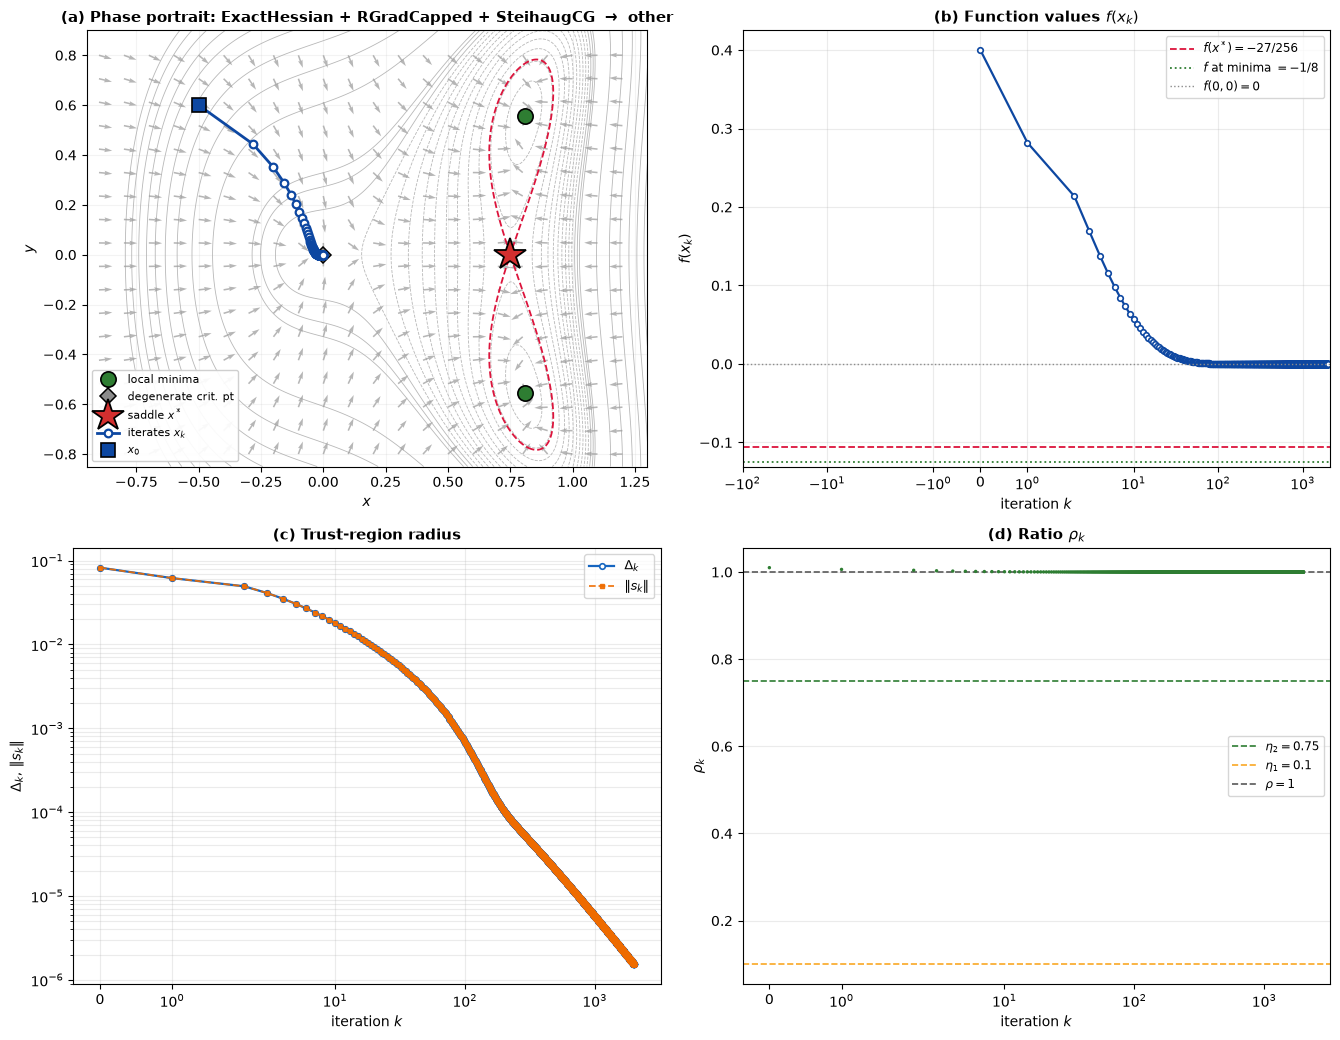

In [6]:
fig_small = diagnose(rule = mk_cap(0.05), model = ExactHessian(),
                     subsolver = SteihaugCG(), kmax = KMAX, tol = TOL,
                     savepath = joinpath(SADDLEDIR, "exact_steihaug_diag_cap005.png"))

ExactHessian + RGradCapped + SteihaugCG : first_order in 85 iters -> origin


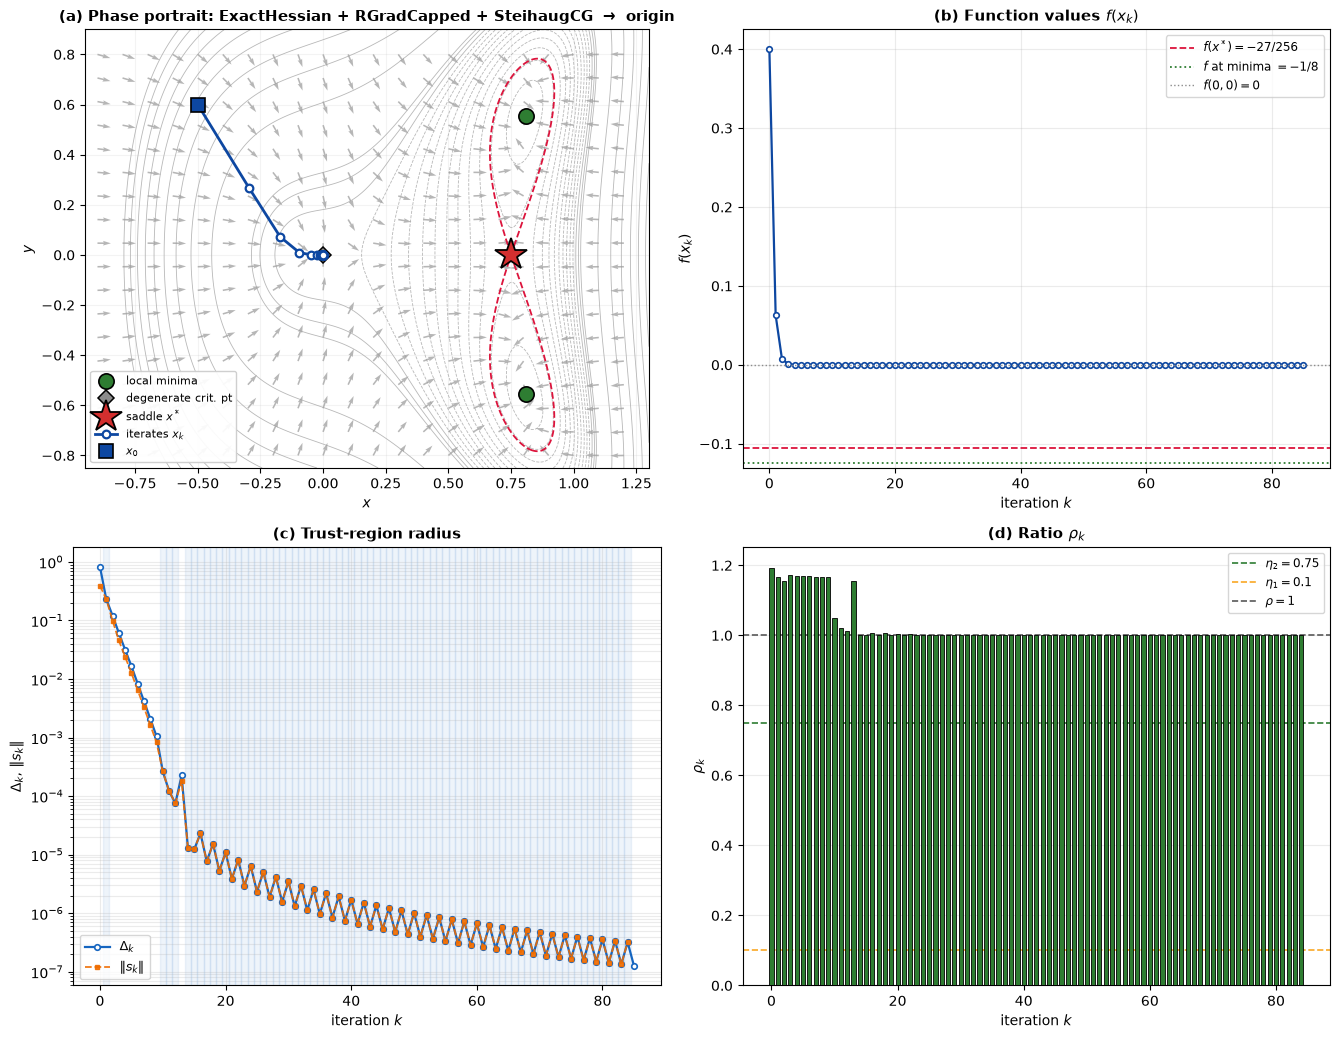

In [7]:
fig_large = diagnose(rule = mk_cap(128.0), model = ExactHessian(),
                     subsolver = SteihaugCG(), kmax = KMAX, tol = TOL,
                     savepath = joinpath(SADDLEDIR, "exact_steihaug_diag_cap128.png"))

ExactHessian + RDFO + SteihaugCG : first_order in 16 iters -> origin


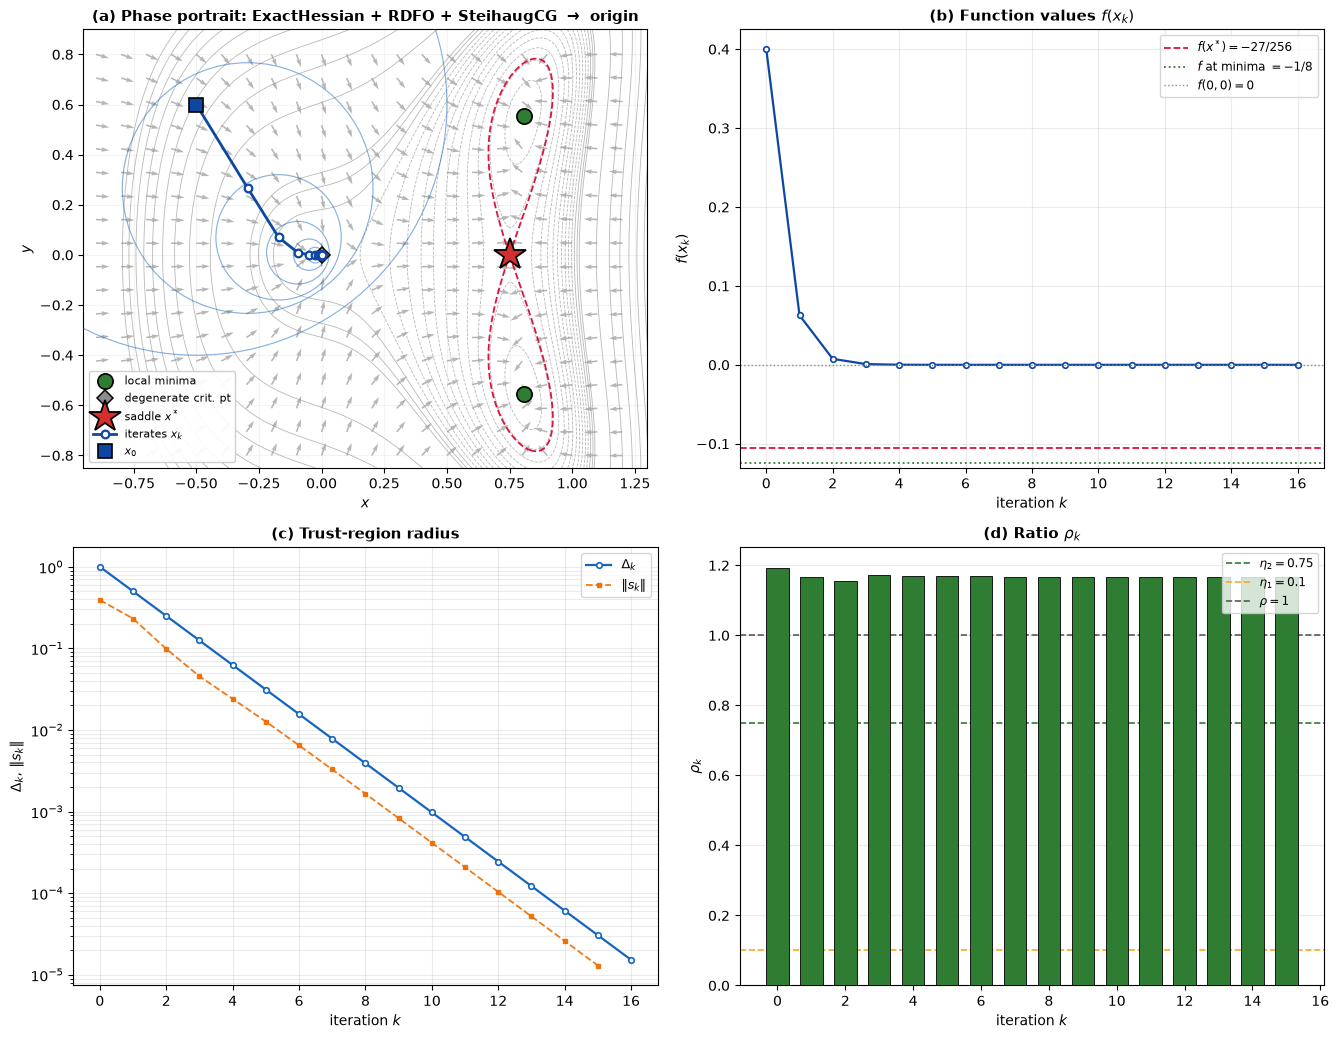

In [8]:
fig_dfo = diagnose(rule = mk_dfo(0.1), model = ExactHessian(),
                   subsolver = SteihaugCG(), kmax = KMAX, tol = TOL,
                   savepath = joinpath(SADDLEDIR, "exact_steihaug_diag_dfo01.png"))

In [ ]:
fig_spd_rgrad = diagnose(rule = mk_dfo(0.1), model = ExactHessian(),
                   subsolver = SteihaugCG(), kmax = KMAX, tol = TOL,
                   savepath = joinpath(SADDLEDIR, "exact_steihaug_diag_dfo01.png"))

## 5. One figure, four regimes

Four runs on the same axes and the same contours, with the trust regions drawn
and the four critical points marked. Small and large $\bar\mu$, small and large
$\zeta$. The caption names the value each panel used.

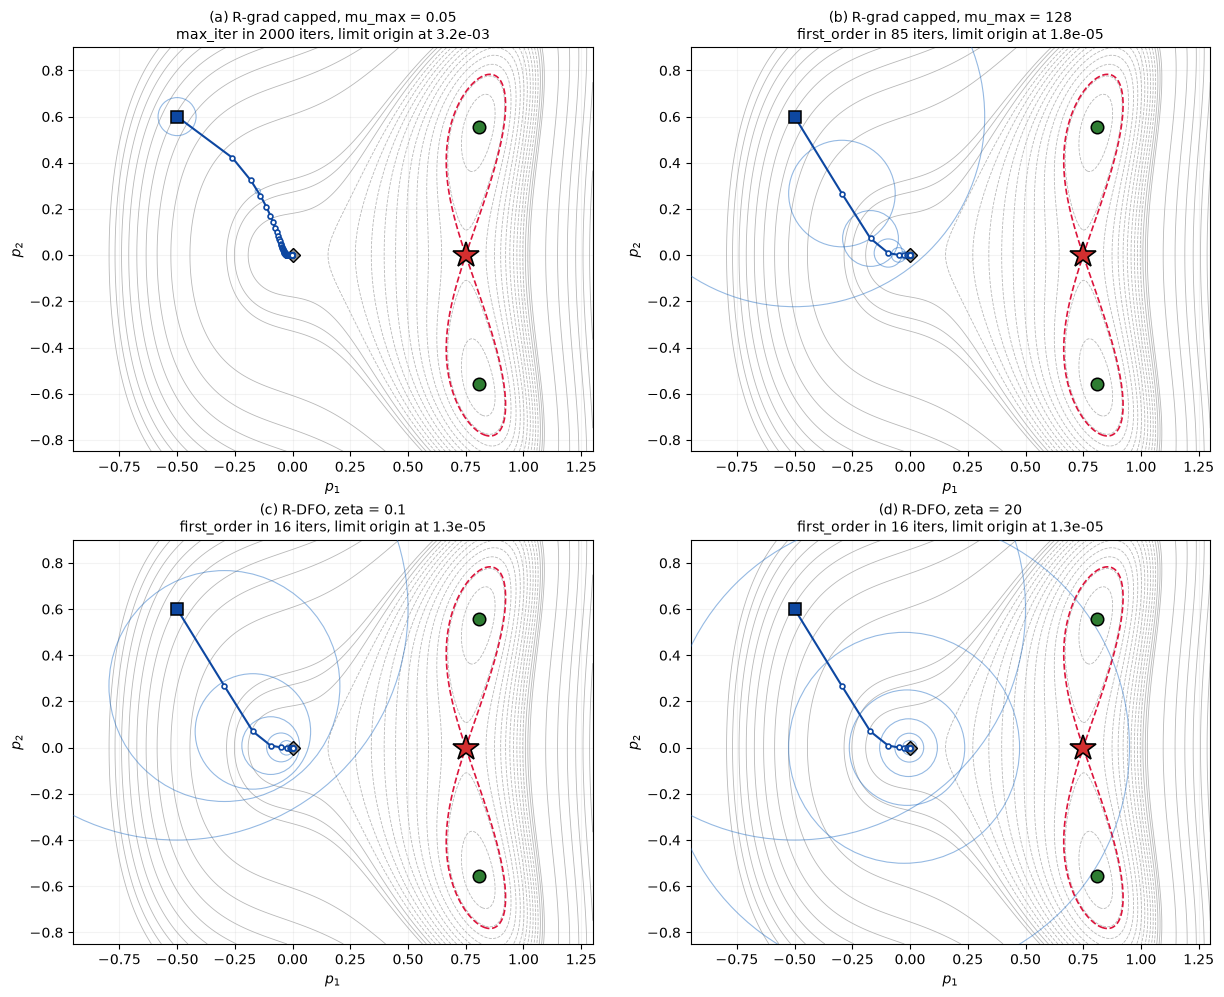

In [9]:
"""
    four_regimes(specs; savepath) -> figure

One panel per entry of `specs`, which is `(label, rule)`. Same axes, same
contours, the trust region of every accepted step, and the four critical points.
Each panel runs `solve_path`, so the iterates come from the solver's callback.
"""
function four_regimes(specs; savepath = nothing)
    xg = range(-0.95, 1.30, length = 420)
    yg = range(-0.85, 0.90, length = 380)
    Xg = [xi for yi in yg, xi in xg]
    Yg = [yi for yi in yg, xi in xg]
    Zg = @. Xg^4 - Xg^3 + (0.25 - Xg/2)*Yg^2 + Yg^4/4
    lv = sort(vcat(collect(range(-0.13, 0.02, length = 14)),
                   collect(range(0.03, 0.9, length = 10))))

    fig = PyPlot.figure(figsize = (12.5, 10.0))
    for (i, (label, rule)) in enumerate(specs)
        st, xs = solve_path(rule = rule, model = ExactHessian(),
                            subsolver = SteihaugCG(), kmax = KMAX, tol = TOL)
        ss = st.solver_specific
        Δv = ss[:delta_trajectory]; cv = ss[:accepted_trajectory]
        P  = reduce(hcat, xs)
        nc = nearest_crit(st.solution)

        ax = fig.add_subplot(2, 2, i)
        ax.contour(Xg, Yg, Zg, levels = lv, colors = "0.72", linewidths = 0.6, zorder = 1)
        ax.contour(Xg, Yg, Zg, levels = [f(SADDLE)], colors = "crimson",
                   linewidths = 1.2, linestyles = "--", zorder = 2)
        # One circle per accepted step, thinned so a two thousand iteration run
        # does not paint two thousand patches on one panel.
        acc = [j for j in 1:length(cv) if cv[j]]
        st_r = max(1, length(acc) ÷ 120)
        for j in acc[1:st_r:end]
            ax.add_patch(PyPlot.matplotlib.patches.Circle((P[1, j], P[2, j]), Δv[j],
                         fill = false, ec = "#1565c0", lw = 0.8, alpha = 0.45, zorder = 3))
        end
        ax.plot([MINP[1], MINM[1]], [MINP[2], MINM[2]], "o", ms = 9, mfc = "#2e7d32",
                mec = "k", mew = 1.1, zorder = 6)
        ax.plot([ORIGIN[1]], [ORIGIN[2]], "D", ms = 7, mfc = "0.55", mec = "k",
                mew = 1.0, zorder = 6)
        ax.plot([SADDLE[1]], [SADDLE[2]], "*", ms = 19, mfc = "#d32f2f", mec = "k",
                mew = 1.2, zorder = 7)
        stride = max(1, size(P, 2) ÷ 300)
        idx = unique(vcat(1:stride:size(P, 2), size(P, 2)))
        ax.plot(P[1, idx], P[2, idx], "-o", color = "#0d47a1", ms = 3.5, lw = 1.5,
                mfc = "white", mec = "#0d47a1", mew = 1.2, zorder = 8)
        ax.plot([P[1, 1]], [P[2, 1]], "s", ms = 8, mfc = "#0d47a1", mec = "k",
                mew = 1.1, zorder = 9)
        ax.set_title(@sprintf("(%s) %s\n%s in %d iters, limit %s at %.1e",
                              "abcd"[i], label, string(st.status), st.iter,
                              nc.name, nc.dist), fontsize = 10)
        ax.set_xlabel("\$p_1\$"); ax.set_ylabel("\$p_2\$")
        ax.set_xlim(-0.95, 1.30); ax.set_ylim(-0.85, 0.90)
        ax.set_aspect("equal"); ax.grid(alpha = 0.14)
    end
    PyPlot.tight_layout()
    savepath === nothing || PyPlot.savefig(savepath, dpi = 165, bbox_inches = "tight")
    return fig
end

FOUR = [("R-grad capped, mu_max = 0.05", mk_cap(0.05)),
        ("R-grad capped, mu_max = 128",  mk_cap(128.0)),
        ("R-DFO, zeta = 0.1",            mk_dfo(0.1)),
        ("R-DFO, zeta = 20",             mk_dfo(20.0))]
fig4 = four_regimes(FOUR;
                    savepath = joinpath(SADDLEDIR, "exact_steihaug_fig1_four_regimes.pdf"))

In [ ]:
"""
    four_regimes(specs; savepath) -> figure

One panel per entry of `specs`, which is `(label, rule)`. Same axes, same
contours, the trust region of every accepted step, and the four critical points.
Each panel runs `solve_path`, so the iterates come from the solver's callback.
"""
function four_regimes(specs; savepath = nothing)
    xg = range(-0.95, 1.30, length = 420)
    yg = range(-0.85, 0.90, length = 380)
    Xg = [xi for yi in yg, xi in xg]
    Yg = [yi for yi in yg, xi in xg]
    Zg = @. Xg^4 - Xg^3 + (0.25 - Xg/2)*Yg^2 + Yg^4/4
    lv = sort(vcat(collect(range(-0.13, 0.02, length = 14)),
                   collect(range(0.03, 0.9, length = 10))))

    fig = PyPlot.figure(figsize = (12.5, 10.0))
    for (i, (label, rule)) in enumerate(specs)
        st, xs = solve_path(rule = rule, model = ExactHessian(),
                            subsolver = SteihaugCG(), kmax = KMAX, tol = TOL)
        ss = st.solver_specific
        Δv = ss[:delta_trajectory]; cv = ss[:accepted_trajectory]
        P  = reduce(hcat, xs)
        nc = nearest_crit(st.solution)

        ax = fig.add_subplot(2, 2, i)
        ax.contour(Xg, Yg, Zg, levels = lv, colors = "0.72", linewidths = 0.6, zorder = 1)
        ax.contour(Xg, Yg, Zg, levels = [f(SADDLE)], colors = "crimson",
                   linewidths = 1.2, linestyles = "--", zorder = 2)
        # One circle per accepted step, thinned so a two thousand iteration run
        # does not paint two thousand patches on one panel.
        acc = [j for j in 1:length(cv) if cv[j]]
        st_r = max(1, length(acc) ÷ 120)
        for j in acc[1:st_r:end]
            ax.add_patch(PyPlot.matplotlib.patches.Circle((P[1, j], P[2, j]), Δv[j],
                         fill = false, ec = "#1565c0", lw = 0.8, alpha = 0.45, zorder = 3))
        end
        ax.plot([MINP[1], MINM[1]], [MINP[2], MINM[2]], "o", ms = 9, mfc = "#2e7d32",
                mec = "k", mew = 1.1, zorder = 6)
        ax.plot([ORIGIN[1]], [ORIGIN[2]], "D", ms = 7, mfc = "0.55", mec = "k",
                mew = 1.0, zorder = 6)
        ax.plot([SADDLE[1]], [SADDLE[2]], "*", ms = 19, mfc = "#d32f2f", mec = "k",
                mew = 1.2, zorder = 7)
        stride = max(1, size(P, 2) ÷ 300)
        idx = unique(vcat(1:stride:size(P, 2), size(P, 2)))
        ax.plot(P[1, idx], P[2, idx], "-o", color = "#0d47a1", ms = 3.5, lw = 1.5,
                mfc = "white", mec = "#0d47a1", mew = 1.2, zorder = 8)
        ax.plot([P[1, 1]], [P[2, 1]], "s", ms = 8, mfc = "#0d47a1", mec = "k",
                mew = 1.1, zorder = 9)
        ax.set_title(@sprintf("(%s) %s\n%s in %d iters, limit %s at %.1e",
                              "abcd"[i], label, string(st.status), st.iter,
                              nc.name, nc.dist), fontsize = 10)
        ax.set_xlabel("\$p_1\$"); ax.set_ylabel("\$p_2\$")
        ax.set_xlim(-0.95, 1.30); ax.set_ylim(-0.85, 0.90)
        ax.set_aspect("equal"); ax.grid(alpha = 0.14)
    end
    PyPlot.tight_layout()
    savepath === nothing || PyPlot.savefig(savepath, dpi = 165, bbox_inches = "tight")
    return fig
end

FOUR = [("R-grad capped, mu_max = 0.05", mk_cap(0.05)),
        ("R-grad capped, mu_max = 128",  mk_cap(128.0)),
        ("R-DFO, zeta = 0.1",            mk_dfo(0.1)),
        ("R-DFO, zeta = 20",             mk_dfo(20.0))]
fig4 = four_regimes(FOUR;
                    savepath = joinpath(SADDLEDIR, "exact_steihaug_fig1_four_regimes.pdf"))

## 6. Does ExactMS degenerate too?

The exact solution is $s^\ast = -(H+\sigma I)^{-1}g$ with $\sigma \to \infty$ as
$\Delta \to 0$, so the step approaches the $-g$ direction without ever reaching
it. The deviation should vanish with $\Delta$.

`step_classes` returns `NaN` here, since `ExactMS` reports `cg_iters == 0`, so
the angle is read instead. The contrast with truncated conjugate gradient, where
the same quantity is identically zero on the truncated branch, is the point of
this section. A small cap degenerates any subsolver, and truncated conjugate
gradient makes the degeneration exact rather than asymptotic.

The fit is $1 - \cos(s_k,-g_k)$ against $\Delta_k$, on a log-log scale, with the
slope, the intercept, $R^2$ and the point count reported. The intercept is
compared with `spectrum_variance` at the returned point.

In [10]:
CAP_MS = [sweep_row(mk_cap(μm); subsolver = ExactMS()) for μm in MU_SWEEP]
sweep_table(CAP_MS, MU_SWEEP, "mu_max";
            title = "TABLE 3. R-grad capped, exact Hessian, exact Moré-Sorensen.")


TABLE 3. R-grad capped, exact Hessian, exact Moré-Sorensen.
  mu_max     status   iter |   cauchy cos last |   cos min  cos frac  tail act |    trunc   inside   krylov | Delta end | limit        dist       |g|
--------------------------------------------------------------------------------------------------------------------------------
    0.01   max_iter   2000 |   0.0000  1.00000 |  0.999899    0.0000    1.0000 |      NaN      NaN      NaN | 6.19e-06 | origin   1.42e-02  6.19e-04
    0.05   max_iter   2000 |   0.6910  1.00000 |  0.996768    0.6910    1.0000 |      NaN      NaN      NaN | 1.54e-06 | origin   3.20e-03  3.08e-05
    0.10   max_iter   2000 |   0.8385  1.00000 |  0.983016    0.8385    1.0000 |      NaN      NaN      NaN | 7.98e-07 | origin   1.63e-03  7.98e-06
    0.30   max_iter   2000 |   0.9435  1.00000 |  0.877285    0.9435    1.0000 |      NaN      NaN      NaN | 2.73e-07 | origin   5.50e-04  9.09e-07
    0.50   max_iter   2000 |   0.9660  1.00000 |  0.877285    0.

In [11]:
println("\n", "="^126)
println("TABLE 4. The angle law under ExactMS. 1 - cos(s_k,-g_k) against Delta_k, log-log.")
println("="^126)
@printf("%8s %7s | %9s %9s %9s %6s | %11s %11s %11s | %11s %9s\n",
        "mu_max", "iter", "slope", "inter", "R2", "n",
        "specvar 1st", "specvar med", "specvar end", "ratio med", "ratio n")
println("-"^126)
ANGLE = NamedTuple[]
med(v) = isempty(v) ? NaN : (t = sort(v); m = length(t);
                             isodd(m) ? t[(m+1)÷2] : (t[m÷2] + t[m÷2+1]) / 2)
for (μm, r) in zip(MU_SWEEP, CAP_MS)
    ss = r.st.solver_specific
    Δ  = ss[:delta_trajectory][1:end-1]        # pair Delta_k with the step it took
    g  = ss[:grad_trajectory][1:end-1]
    y  = 1 .- ss[:cos_cauchy_trajectory]
    n  = min(length(Δ), length(y), length(g))
    fΔ = loglog_fit(Δ[1:n], y[1:n])

    # The law to test is 1 - cos ~ (1/2) Var_w(lambda) (Delta/|g|)^2, with
    # Var_w the g-weighted spectral variance. It is a per-iterate quantity and
    # not a constant, so it is read along the run and the law is tested
    # directly rather than through the intercept alone.
    sv = [spectrum_variance(r.xs[i]) for i in 1:n]
    pred = [0.5 * sv[i] * (Δ[i] / max(g[i], 1e-300))^2 for i in 1:n]
    rat  = [y[i] / pred[i] for i in 1:n
            if isfinite(y[i]) && isfinite(pred[i]) && y[i] > 0 && pred[i] > 0]
    push!(ANGLE, (mu_max = μm, fit_delta = fΔ, specvar = sv, ratio = rat))
    @printf("%8.2f %7d | %9.4f %9.4f %9.5f %6d | %11.3e %11.3e %11.3e | %11.4f %9d\n",
            μm, r.iter, fΔ.slope, fΔ.inter, fΔ.r2, fΔ.n,
            isempty(sv) ? NaN : sv[1], med(filter(isfinite, sv)),
            isempty(sv) ? NaN : sv[end], med(rat), length(rat))
end
println()
println("`ratio med` is the median of (1 - cos) divided by (1/2) Var_w (Delta/|g|)^2,")
println("so a value of one is the law holding and the fitted slope is a separate")
println("question. `specvar` is read at the first iterate, at the median and at the")
println("last, because the law has that quantity as its coefficient and a coefficient")
println("that moves over four orders of magnitude is not a constant to fit an")
println("intercept against.")


TABLE 4. The angle law under ExactMS. 1 - cos(s_k,-g_k) against Delta_k, log-log.
  mu_max    iter |     slope     inter        R2      n | specvar 1st specvar med specvar end |   ratio med   ratio n
------------------------------------------------------------------------------------------------------------------------------
    0.01    2000 |    0.7271   -3.7578   0.27146   2000 |   1.910e+00   4.383e-03   1.089e-05 |      0.9951      2000
    0.05    2000 |    3.7386    6.9002   0.60420    873 |   1.910e+00   2.429e-17   0.000e+00 |      0.9601       873
    0.10    2000 |    3.9295    7.0247   0.61639    444 |   1.910e+00   0.000e+00   0.000e+00 |      0.9212       444
    0.30    2000 |    4.5335    7.7878   0.68887    152 |   1.910e+00   0.000e+00   0.000e+00 |      0.7877       152
    0.50    2000 |    4.5363    6.7530   0.71743     92 |   1.910e+00   0.000e+00   0.000e+00 |      0.6781        92
    1.00    2000 |    4.4059    4.7131   0.75283     50 |   1.910e+00   0.000e+00 

In [12]:
# The same quantity under truncated CG, for the contrast the section is about.
println("\n", "="^96)
println("TABLE 5. 1 - cos(s_k,-g_k) under truncated CG, the same runs as Table 1.")
println("="^96)
@printf("%8s %8s %14s %14s %14s\n", "mu_max", "iter", "min", "median", "max")
println("-"^96)
for (μm, r) in zip(MU_SWEEP, CAP_CG)
    y = 1 .- r.st.solver_specific[:cos_cauchy_trajectory]
    y = filter(isfinite, y)
    if isempty(y)
        @printf("%8.2f %8d %14s %14s %14s\n", μm, r.iter, "n/a", "n/a", "n/a")
    else
        s = sort(y); m = length(s)
        mdn = isodd(m) ? s[(m+1)÷2] : (s[m÷2] + s[m÷2+1]) / 2
        @printf("%8.2f %8d %14.6e %14.6e %14.6e\n", μm, r.iter, s[1], mdn, s[end])
    end
end


TABLE 5. 1 - cos(s_k,-g_k) under truncated CG, the same runs as Table 1.
  mu_max     iter            min         median            max
------------------------------------------------------------------------------------------------
    0.01     2000  -4.440892e-16   0.000000e+00   4.440892e-16
    0.05     2000  -4.440892e-16   0.000000e+00   3.330669e-16
    0.10     2000  -4.440892e-16   0.000000e+00   3.330669e-16
    0.30     2000  -2.220446e-16   0.000000e+00   1.227149e-01
    0.50     2000  -2.220446e-16   0.000000e+00   1.227149e-01
    1.00     2000  -2.220446e-16   0.000000e+00   1.227149e-01
    2.00     2000  -2.220446e-16   0.000000e+00   1.227149e-01
    4.00     2000  -2.220446e-16   6.739873e-07   1.227149e-01
    8.00     1678  -2.220446e-16   9.549879e-03   3.243360e-01
  128.00       85   0.000000e+00   6.739976e-02   7.535429e-01


In [13]:
println("\nDONE. Figures written to ", SADDLEDIR)


DONE. Figures written to c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks\FINAL\Degenerate_TCG
